In [1]:
# set auto-reload of the notebook
%load_ext autoreload
%autoreload 2

In [2]:
import cns
import cns.data_utils as cdu
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 10)
# set color_map to tab10
color_map = plt.cm.get_cmap('tab10').colors[:10]
plt.rcParams.update({'font.size': 12})

C:\Users\adams\AppData\Local\Temp\ipykernel_48820\1427791538.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab10').colors[:10]


In [3]:
samples_df, cns_df = cdu.main_load("10MB")

In [4]:
lusc_df = cns.group_samples(cns.only_aut(cns.add_total_cn(cns.select_cns_by_type(cns_df, samples_df, "LUSC"))))
lusc_df["sample_id"] = "mean LUSC CN"
lusc_df["score"] = cns.calc_angles(lusc_df, "total_cn")
luad_df = cns.group_samples(cns.only_aut(cns.add_total_cn(cns.select_cns_by_type(cns_df, samples_df, "LUAD"))))
luad_df["sample_id"] = "mean LUAD CN"
luad_df["score"] = cns.calc_angles(luad_df, "total_cn")

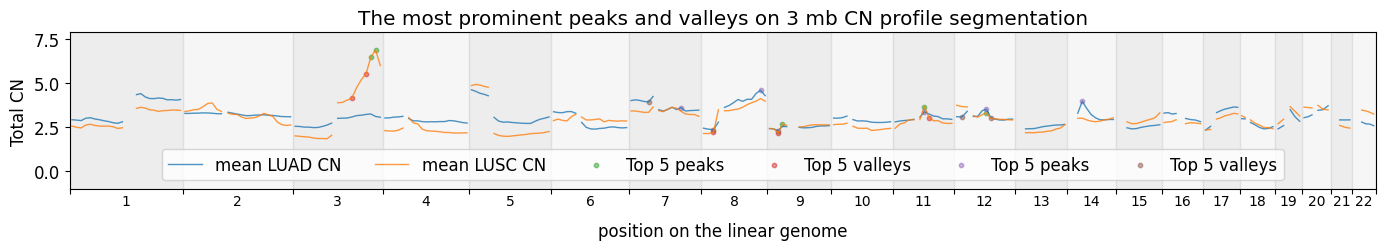

In [8]:
feature = "score"
val_count = 5
# indices of top 5 values

fig, ax = cns.fig_lines(pd.concat([lusc_df, luad_df]), cn_columns="total_cn", colors=[color_map[0], color_map[1]])
fig.set_size_inches(14, 2)

for i, sel_df in enumerate([lusc_df, luad_df]):
	sel_df = cns.add_cum_mid(sel_df)
	sel_df = sel_df.sort_values(by="score")
	ax.scatter(sel_df["cum_mid"].head(5), sel_df["total_cn"].head(5), color=color_map[2 + i*2], alpha=0.5, s=10, label="Top 5 peaks")
	ax.scatter(sel_df["cum_mid"].tail(5), sel_df["total_cn"].tail(5), color=color_map[3 + i*2], alpha=0.5, s=10, label="Top 5 valleys")

plt.title("The most prominent peaks and valleys on 3 mb CN profile segmentation")
plt.ylabel("Total CN")

# legend with 3 columns
ax.legend(loc="lower center", ncol=6)

cdu.save_cns_fig("3MB_cns_peaks_valleys")

In [10]:
cosmic = cdu.load_COSMIC()

In [14]:
luad_means = []
lusc_means = []
for grouping in ["10MB", "5MB", "3MB", "2MB", "1MB", "500KB", "250KB"]:
	print(grouping)
	samples_df, cns_df = cdu.main_load(grouping)
	lusc_df = cns.group_samples(cns.only_aut(cns.add_total_cn(cns.select_cns_by_type(cns_df, samples_df, "LUSC"))))
	lusc_df["sample_id"] = "mean LUSC CN"
	lusc_df["score"] = cns.calc_angles(lusc_df, "total_cn")
	lusc_means.append(cns.mean_value_per_seg(luad_df, cosmic, "score"))
	luad_df = cns.group_samples(cns.only_aut(cns.add_total_cn(cns.select_cns_by_type(cns_df, samples_df, "LUAD"))))
	luad_df["sample_id"] = "mean LUAD CN"
	luad_df["score"] = cns.calc_angles(luad_df, "total_cn")
	luad_means.append(cns.mean_value_per_seg(luad_df, cosmic, "score"))

10MB
5MB
3MB
2MB
1MB
500KB
250KB


In [23]:
lusc_mean = lusc_means[0].copy()
for vals in lusc_means[1:]:
	lusc_mean["score"] += vals["score"]
lusc_mean["score"] /= len(lusc_means)
lusc_mean["total_cn"] = cns.mean_value_per_seg(lusc_df, cosmic, "total_cn")["total_cn"]
print(lusc_mean.sort_values(by="score", ascending=True).head(10))


     chrom      start        end    name     score  total_cn
198  chr14   36985601   36990354  NKX2-1 -0.791616  3.108557
197  chr14   35221936   35344853   BAZ1A -0.698462  3.001560
165  chr12   69201955   69239214    MDM2 -0.634620  3.419150
199  chr14   38059188   38069245   FOXA1 -0.606929  3.185075
645   chr8  128747679  128753674     MYC -0.433302  4.476789
113  chr11   69455854   69469242   CCND1 -0.351830  5.861743
161  chr12   58141509   58149796    CDK4 -0.326255  3.182825
603   chr7  116312443  116438440     MET -0.294276  3.413896
160  chr12   57910370   57914300   DDIT3 -0.263823  3.169472
195  chr14   30045686   30661104   PRKD1 -0.251385  2.929576


In [22]:
cns.mean_value_per_seg(lusc_df, cosmic, "total_cn")

,chrom,start,end,name,total_cn
0,chr1,2160133,2241558,SKI,2.593026
1,chr1,2487077,2496821,TNFRSF14,2.585614
2,chr1,2985731,3355185,PRDM16,2.570486
3,chr1,6241328,6269449,RPL22,2.540913
4,chr1,6845383,7829766,CAMTA1,2.526282
...,...,...,...,...,...
676,chr9,134000947,134110057,NUP214,2.623807
677,chr9,135766734,135820020,TSC1,2.627394
678,chr9,135973106,136039301,RALGDS,2.627796
679,chr9,136895426,136933657,BRD3,2.622279


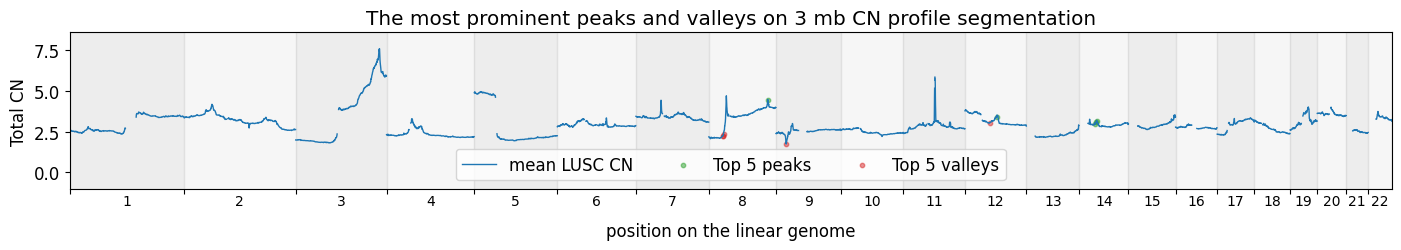

In [24]:
feature = "score"
val_count = 5
# indices of top 5 values

fig, ax = cns.fig_lines(lusc_df, cn_columns="total_cn", colors=color_map[0])
fig.set_size_inches(14, 2)

for i, sel_df in enumerate([lusc_mean]):
	sel_df = cns.add_cum_mid(sel_df)
	sel_df = sel_df.sort_values(by="score")
	ax.scatter(sel_df["cum_mid"].head(5), sel_df["total_cn"].head(5), color=color_map[2 + i*2], alpha=0.5, s=10, label="Top 5 peaks")
	ax.scatter(sel_df["cum_mid"].tail(5), sel_df["total_cn"].tail(5), color=color_map[3 + i*2], alpha=0.5, s=10, label="Top 5 valleys")

plt.title("The most prominent peaks and valleys on 3 mb CN profile segmentation")
plt.ylabel("Total CN")

# legend with 3 columns
ax.legend(loc="lower center", ncol=6)

cdu.save_cns_fig("3MB_cns_peaks_valleys")